In [1]:
%load_ext autoreload

%autoreload 2

In [2]:
from turborocket.profiling.Supersonic.transition import method_of_characteristics
from turborocket.profiling.Supersonic.circular import prandtl_meyer
from turborocket.profiling.Supersonic.supersonic_profile import SupersonicProfile

from turborocket.fluids.fluids import IdealGas

import numpy as np

import matplotlib.pyplot as plt


In [484]:
gamma = 1.4

v_i = prandtl_meyer(gamma, 1.5)
v_l = prandtl_meyer(gamma, 2.2)
k_max = 20

print(f"Prantdl Meyer Angles")
print(f"v_i: {v_i}")
print(f"v_l: {v_l}")

np.arange(start = 3, stop= k_max + 2, step=1)

np.linspace(3,1,3)


Prantdl Meyer Angles
v_i: 0.327233212037355
v_l: 1.2665826032604717


array([3., 2., 1.])

In [487]:
x, y = method_of_characteristics(k_max=k_max, v_i=v_i, v_l=v_l, gamma=gamma, alpha_l_i=0, reverse_x=True)

line = test.straight_zone(beta_m=-(v_i-v_l), initial_coord=(x[-1], y[-1]), x_f=-0.6 )

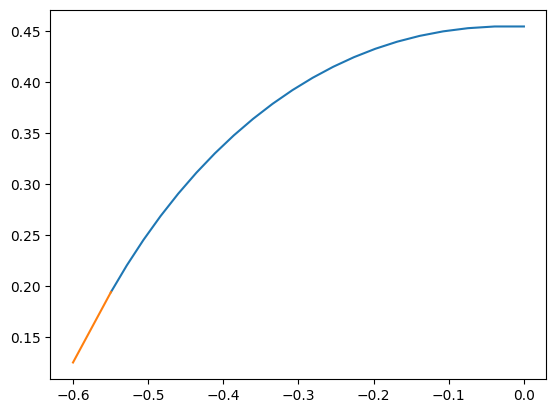

In [488]:
plt.plot(x, y)
plt.plot(line[:,0], line[:,1])

In [1751]:
gas = IdealGas(p=100e5, t=295, name="test", cp=1004, gamma=1.2)

In [1779]:
test = SupersonicProfile(beta=(-67, 67),
                         M_r=(2, 2),
                         M_s=(1.5, 2.2),
                         t_g_rat = 0.2,
                         g_expand = 0,
                         k_max=50,
                         fluid=gas)

################################################################################
#                              Constraint Report                               #
################################################################################

M_i_star: 1.7728105208558367
M_i_star_max: 1.7958392149036022

M_u_star: 1.4214106244380287
M_u_star_max: 2.1164415763017583

M_l_star: 1.8940963751000415
M_l_star_min: 1.4280900371067469


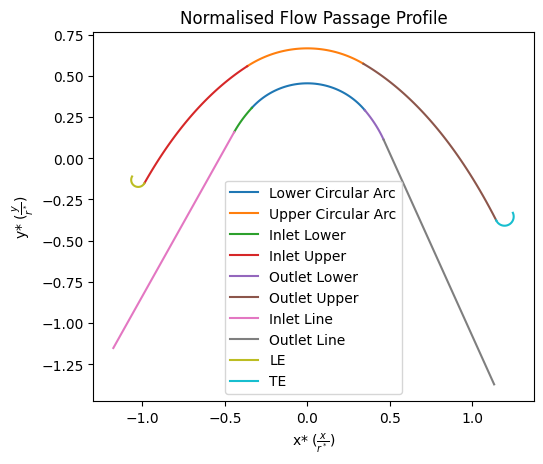

In [1770]:
test.plot_passage()

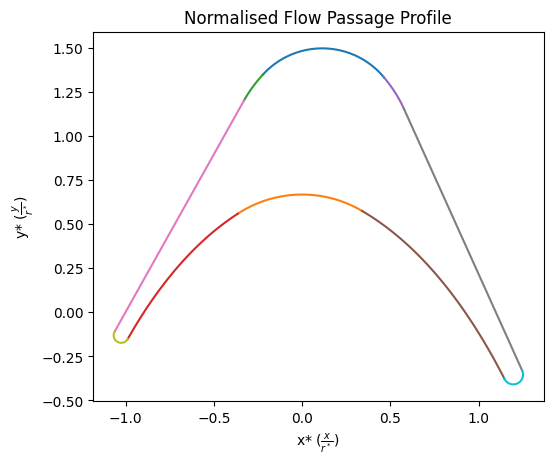

In [1771]:
test.plot_blade()

In [1772]:
sf = test.size_geometry(D_m=0.1, N=35)

print(f"Scaling Factor {sf}")

Scaling Factor 0.008572632804029591


In [1773]:
df = test.generate_xy(sf=sf*1e3)

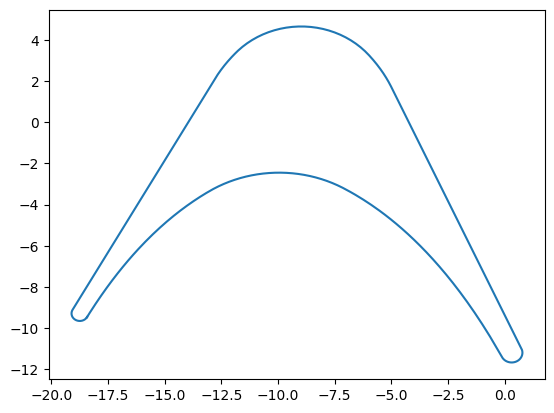

In [1774]:
plt.plot(df["x"], df["y"])
df.to_csv("blade.txt", sep="\t", index=False, header=False)